# Combined overview: velocity & bathymetry profiles across the test160–test239 suite

This notebook recreates the profiles used in each of the four initial-condition notebooks
(`create_ic_160_189_width_tanh_U02__300m.ipynb`, `create_ic_190_207_height_tanh_U02_300m.ipynb`,
`create_ic_208_227_width_tanh_U02__300m.ipynb`, `create_ic_228_239_Yj_varies_tanh_U02_300m.ipynb`)
and plots them side-by-side so the whole 80-experiment suite can be understood at a glance.

It does **not** read any of the generated NetCDF files — it just re-evaluates the same
tanh formulas used to build the initial conditions, so it's fast and self-contained.

| Notebook | Tests | # exps | U (m/s) | Ljet varied | Slope width | Slope height | Yj |
|---|---|---|---|---|---|---|---|
| `160_189_width` | test160–189 | 30 | 0.2 | 5, 10, 15 km | varies: 5–95 km | fixed: 400 m | fixed: 200 km |
| `190_207_height` | test190–207 | 18 | 0.2 | 5, 10 km | fixed: 55 km | varies: 25–375 m | fixed: 200 km |
| `208_227_width` | test208–227 | 20 | 0.3 | 5, 10 km | varies: 5–95 km | fixed: 400 m | fixed: 200 km |
| `228_239_Yj` | test228–239 | 12 | 0.2 | fixed: 5 km | fixed: 55 km | fixed: 400 m | varies: 150–250 km |


### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Shared domain and helper functions

Same `yh` grid and tanh formulas as used in all four source notebooks.

In [2]:
# ---- shared domain (matches all 4 source notebooks) ----
Ly = 400e3        # m
dy = 300          # m
ny = int(Ly / dy)
yh = np.linspace(dy/2, ny*dy - dy/2, ny)

f = -1e-5   # s^-1
g = 9.81    # m s^-2

Ys = 200.0  # km, slope centre (fixed across all experiments)


def tanh_bathy(yh, Ys_m, shallow, deep, width_km):
    """Single tanh bathymetry profile, matching make_bathy_tanh() in the source notebooks.
    steepness is set so 90% of the depth change occurs within width_km.
    """
    steepness = (width_km * 1e3) / (2 * np.arctanh(0.95))
    return shallow + (deep - shallow) * (np.tanh((yh - Ys_m) / steepness) + 1) / 2


def u_profile(yh, Yj_km, Ljet_km, U):
    """Cross-shelf velocity profile u(y) = U * tanh((y - Yj) / Ljet)."""
    return U * np.tanh((yh - Yj_km*1e3) / (Ljet_km*1e3))

### Build the figure

2 rows (velocity, bathymetry) × 4 columns (one per source notebook).

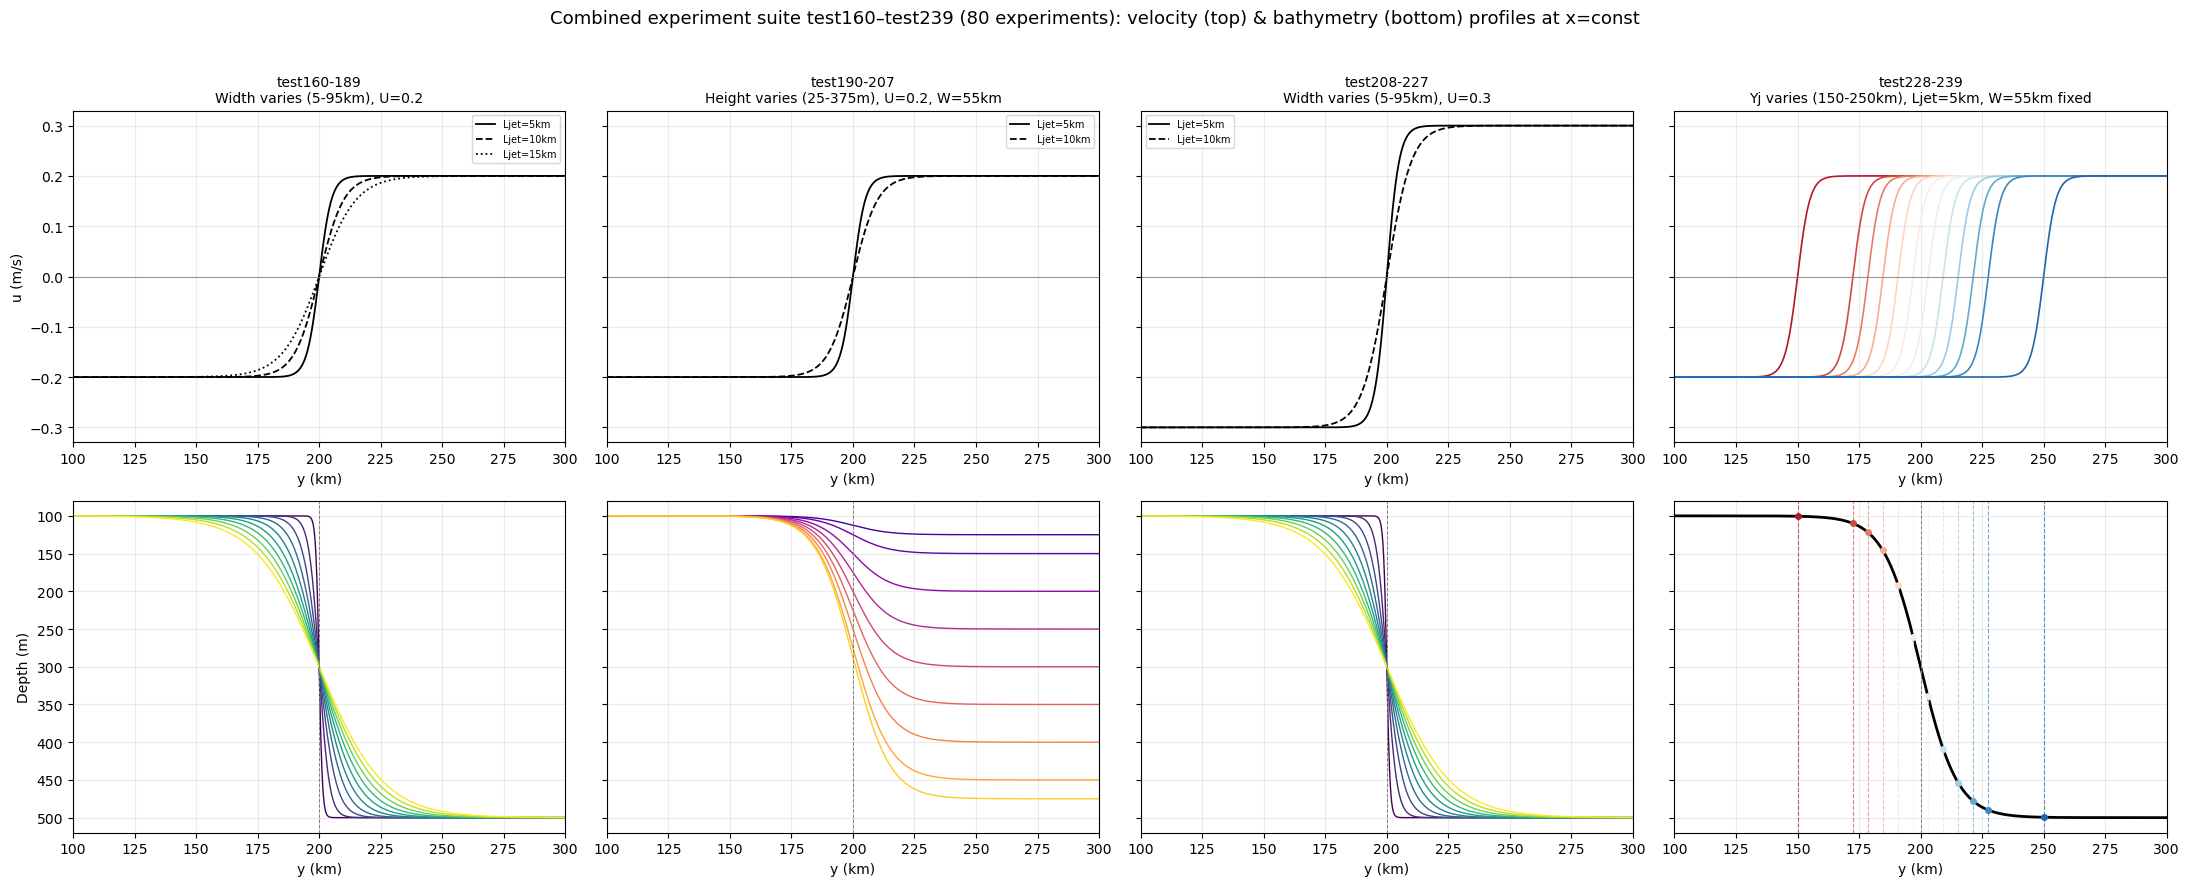

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9), sharey='row')

# ============ Column 1: test160-189  Width varies, U=0.2, Ljet in {5,10,15} ============
ax_u, ax_b = axes[0, 0], axes[1, 0]
widths = list(range(5, 96, 10))

for Ljet_km, ls in zip([5, 10, 15], ['-', '--', ':']):
    u = u_profile(yh, 200.0, Ljet_km, 0.2)
    ax_u.plot(yh/1e3, u, ls, color='k', lw=1.3, label=f'Ljet={Ljet_km}km')

colors = plt.cm.viridis(np.linspace(0, 1, len(widths)))
for w, c in zip(widths, colors):
    b = tanh_bathy(yh, Ys*1e3, 100, 500, w)
    ax_b.plot(yh/1e3, b, color=c, lw=1)

ax_u.set_title('test160-189\nWidth varies (5-95km), U=0.2', fontsize=10)
ax_u.legend(fontsize=7)

# ============ Column 2: test190-207 Height varies, U=0.2, Ljet in {5,10} ============
ax_u, ax_b = axes[0, 1], axes[1, 1]
heights = [25, 50, 100, 150, 200, 250, 300, 350, 375]

for Ljet_km, ls in zip([5, 10], ['-', '--']):
    u = u_profile(yh, 200.0, Ljet_km, 0.2)
    ax_u.plot(yh/1e3, u, ls, color='k', lw=1.3, label=f'Ljet={Ljet_km}km')

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(heights)))
for h, c in zip(heights, colors):
    b = tanh_bathy(yh, Ys*1e3, 100, 100 + h, 55)
    ax_b.plot(yh/1e3, b, color=c, lw=1)

ax_u.set_title('test190-207\nHeight varies (25-375m), U=0.2, W=55km', fontsize=10)
ax_u.legend(fontsize=7)

# ============ Column 3: test208-227 Width varies, U=0.3, Ljet in {5,10} ============
ax_u, ax_b = axes[0, 2], axes[1, 2]

for Ljet_km, ls in zip([5, 10], ['-', '--']):
    u = u_profile(yh, 200.0, Ljet_km, 0.3)
    ax_u.plot(yh/1e3, u, ls, color='k', lw=1.3, label=f'Ljet={Ljet_km}km')

colors = plt.cm.viridis(np.linspace(0, 1, len(widths)))
for w, c in zip(widths, colors):
    b = tanh_bathy(yh, Ys*1e3, 100, 500, w)
    ax_b.plot(yh/1e3, b, color=c, lw=1)

ax_u.set_title('test208-227\nWidth varies (5-95km), U=0.3', fontsize=10)
ax_u.legend(fontsize=7)

# ============ Column 4: test228-239 Yj varies, U=0.2, Ljet=5, W=55 fixed ============
ax_u, ax_b = axes[0, 3], axes[1, 3]
Yj_values_km = [150.0] + list(np.linspace(172.5, 227.5, 10)) + [250.0]
colors = plt.cm.RdBu(np.linspace(0.1, 0.9, len(Yj_values_km)))
bathy_fixed = tanh_bathy(yh, Ys*1e3, 100, 500, 55)

for yj, c in zip(Yj_values_km, colors):
    u = u_profile(yh, yj, 5, 0.2)
    ax_u.plot(yh/1e3, u, color=c, lw=1.2)

ax_b.plot(yh/1e3, bathy_fixed, 'k', lw=2)
for yj, c in zip(Yj_values_km, colors):
    idx = np.argmin(np.abs(yh - yj*1e3))
    ax_b.axvline(yj, color=c, lw=0.8, ls='--', alpha=0.7)
    ax_b.plot(yj, bathy_fixed[idx], 'o', color=c, ms=4, zorder=5)

ax_u.set_title('test228-239\nYj varies (150-250km), Ljet=5km, W=55km fixed', fontsize=10)

# ---- shared formatting ----
for i, ax in enumerate(axes[0]):
    ax.axhline(0, color='gray', lw=0.6)
    ax.set_xlim(100, 300)
    ax.grid(alpha=0.25)
    if i == 0:
        ax.set_ylabel('u (m/s)')
    ax.set_xlabel('y (km)')

for i, ax in enumerate(axes[1]):
    ax.axvline(200, color='gray', ls='--', lw=0.7)
    ax.set_xlim(100, 300)
    ax.set_ylim(520, 80)   # deep at bottom, shallow (surface) at top
    ax.grid(alpha=0.25)
    if i == 0:
        ax.set_ylabel('Depth (m)')
    ax.set_xlabel('y (km)')

plt.suptitle('Combined experiment suite test160\u2013test239 (80 experiments): '
             'velocity (top) & bathymetry (bottom) profiles at x=const', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Save the figure

Uncomment to write a PNG alongside the notebook.

In [4]:
# fig.savefig('combined_overview.png', dpi=140, bbox_inches='tight')